# ARIMA model

In [180]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [181]:
# Load the data
df = pd.read_csv("data/Daily.csv")
df = df[["Date", "USD"]]
df['USD'] = df['USD'].str.replace(',', '')
df["USD"] = pd.to_numeric(df["USD"])
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y") # Parse dates
df = df[df["Date"] >= "2010-01-01"]
df = df.dropna()
df = df.reset_index(drop=True) # Sort by date
df = df.set_index("Date") # Set date as index
# df = df[df.index.day_of_week < 5] # Filter out weekends

stock = "Gold"

trading_days_per_year = 252

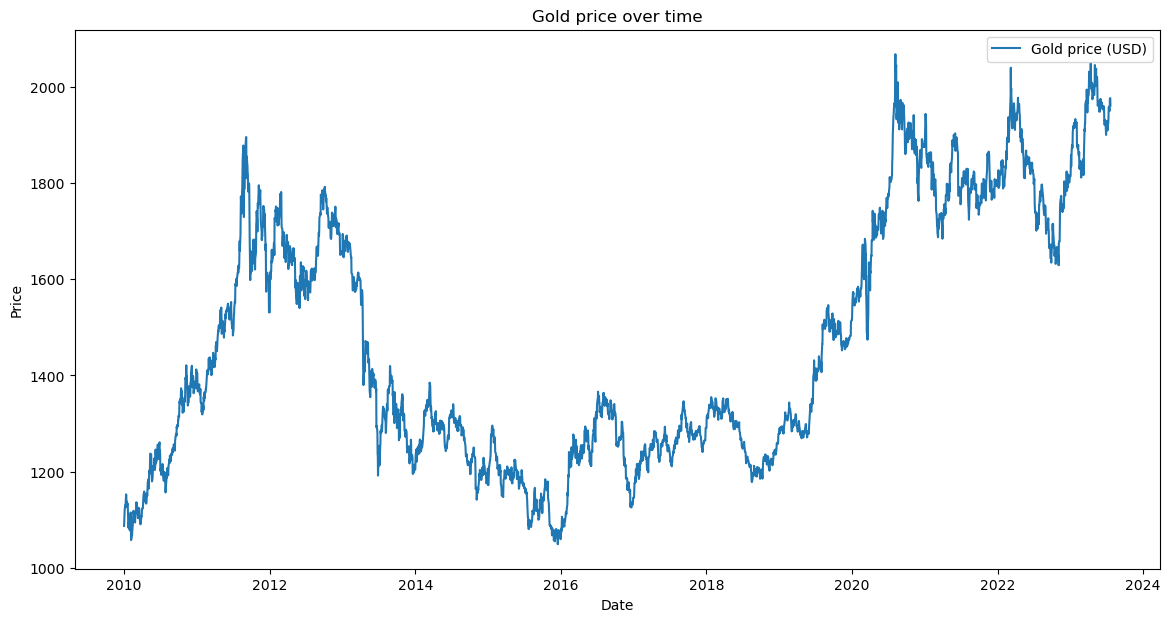

In [182]:
# Create a time plot
plt.figure(figsize=(14, 7))
plt.plot(df.index, df["USD"], label='Gold price (USD)')
plt.title(f'{stock} price over time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

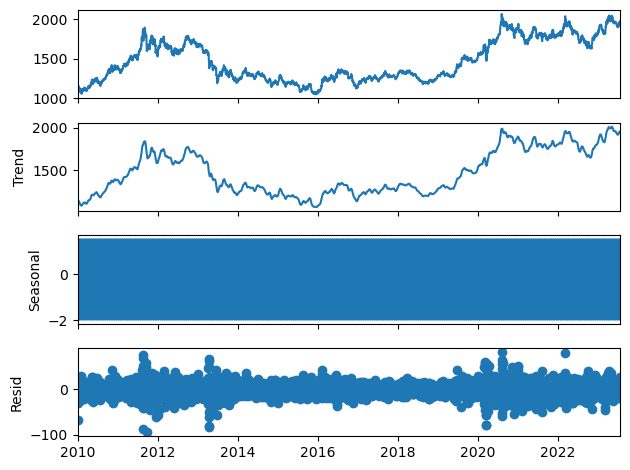

In [183]:
# Check for seasonality by performing classical decomposition
import statsmodels.api as sm
decomposition = sm.tsa.seasonal_decompose(df, model='additive', extrapolate_trend='freq', period=12)
fig = decomposition.plot()
plt.show()

In [184]:
trend = decomposition.trend.dropna()

In [ ]:
# Forecasting
test_period = trading_days_per_year * 5
train_period = len(trend) - test_period

model_fit = pm.auto_arima(
    trend.iloc[:train_period], 
    start_p=0, max_p=5, 
    start_q=0, max_q=5,
    d=None,           # Automatically test and find the best 'd'
    seasonal=False,   # Set to True if your data has a known seasonal cycle
    stepwise=True     # Uses a fast search algorithm instead of checking every combination
)

print(f"Optimal ARIMA order: {model_fit.order}")

In [ ]:
# forecast = pd.Series(model_fit.predict(n_periods=test_period), index=trend.index[train_period:])

forecast = []

for t in range(train_period, len(trend)):
    # Forecast the next value
    next_forecast = model_fit.predict(n_periods=1)[0]
    forecast.append(next_forecast)

    # Update the model with the actual observed value
    model_fit.update(trend.iloc[t], refit=False)

# Convert forecasts to a Series
forecast = pd.Series(forecast, index=trend.index[train_period:])

C:\Users\Ryan Joo\AppData\Local\Temp\ipykernel_3792\3328527114.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


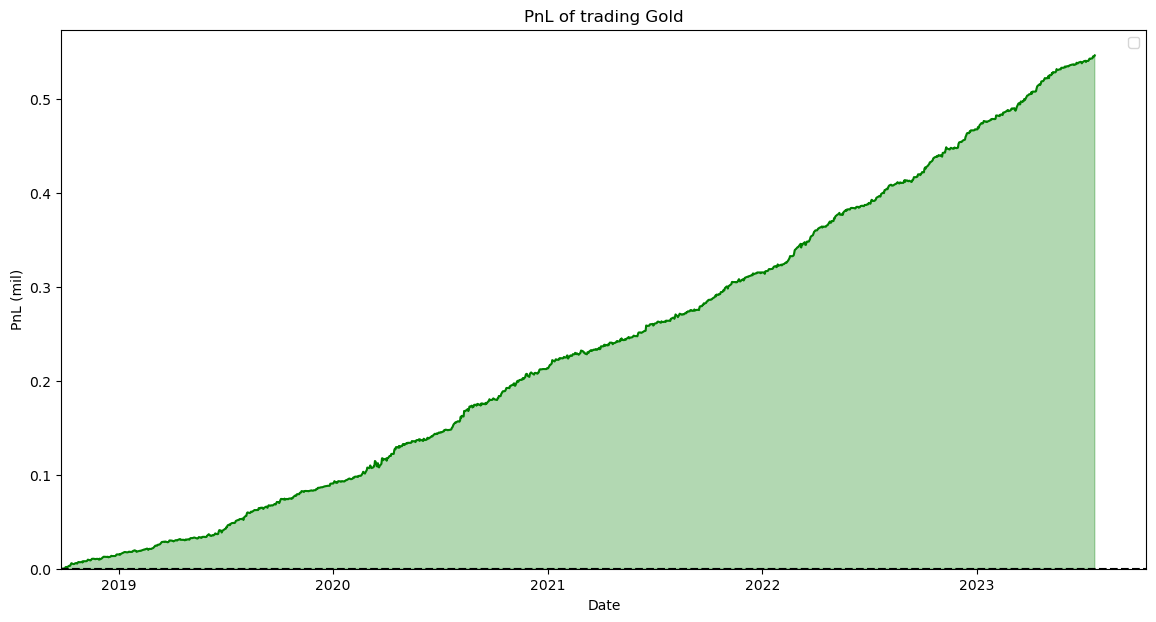

Returns: 54.59%
Up days: 802, Down days: 399, Neutral days: 57
Win rate: 63.75%
Average win/loss ratio: 1.68
Profit factor: 3.37
Sharpe ratio: 6.47


In [ ]:
# Trading strategy: If predict next day price decrease then sell, if predict price increase then buy
# Initial capital is $1 mil
# Assume using 10% of cumulative capital to trade
# Backtest on test data to obtain PnL chart

train = df.iloc[:train_period]
test = df.iloc[train_period:]

# % price change
test_data = test.copy()
test_data = test_data.rename(columns={"trend": stock})
test_data["Actual % change"] = test_data.pct_change()
forecast_price = forecast[:len(test)]
test_data["Forecast price"] = list(forecast_price)

# Trading position: long (+1) if the model predicts the price will increase tomorrow, short (-1) otherwise.
test_data["Predicted change"] = test_data["Forecast price"] - test_data["USD"].shift(1)
cond_list = [
    test_data["Predicted change"] > 0,
    test_data["Predicted change"] < 0,
    test_data["Predicted change"] == 0
]
choice_list = [1, -1, 0]
test_data["Position"] = np.select(cond_list, choice_list)

# Returns
test_data["% returns"] = test_data["Position"] * test_data["Actual % change"]

test_data.dropna(inplace=True)

# Cumulative returns
initial_capital = 1_000_000
allocated_portion = 0.10
# current_capital = 1_000_000
# test_data["Returns"] = 0.0
# test_data["Cumulative returns"] = 0.0
# ret_idx = test_data.columns.get_loc("Returns")
# cum_idx = test_data.columns.get_loc("Cumulative returns")
# for i in range(len(test_data)):
#     returns = current_capital * test_data["% returns"].iloc[i]
#     current_capital += returns
#     test_data.iloc[i, ret_idx] = returns
#     if i == 0:
#         test_data.iloc[0, cum_idx]= returns
#     else:
#         test_data.iloc[i, cum_idx] = test_data.iloc[i-1, cum_idx] + returns

capital_series = initial_capital * (1 + test_data["% returns"] * allocated_portion).cumprod()
starting_capital = capital_series.shift(1, fill_value=initial_capital)
test_data["Returns"] = (starting_capital * allocated_portion) * test_data["% returns"]
test_data["Cumulative returns"] = test_data["Returns"].cumsum()

start_date = test_data.index[0] - pd.Timedelta(days=1)
baseline_df = pd.DataFrame(data={"PnL": 0.0}, index=[start_date])
pnl_df = pd.concat([baseline_df, test_data[["Cumulative returns"]]])

# Plot PnL chart
cum_returns_mil = pnl_df["Cumulative returns"] / 1_000_000
plt.figure(figsize=(14,7))
plt.plot(pnl_df.index, np.where(cum_returns_mil >= 0, cum_returns_mil, np.nan), color='green')
plt.plot(pnl_df.index, np.where(cum_returns_mil < 0, cum_returns_mil, np.nan), color='red')
plt.axhline(y=0, color="black", linestyle='--') # Zero baseline
plt.fill_between(pnl_df.index, cum_returns_mil, 0, where=(cum_returns_mil >= 0), color='green', alpha=0.3)
plt.fill_between(pnl_df.index, cum_returns_mil, 0, where=(cum_returns_mil < 0), color='red', alpha=0.3)
plt.xlim(min(pnl_df.index), None)
plt.ylim(cum_returns_mil.min(), None)
plt.title(f"PnL of trading {stock}")
plt.xlabel("Date")
plt.ylabel("PnL (mil)")
plt.legend()
plt.show()

# Metrics
final_pnl = test_data["Cumulative returns"].iloc[-1]
total_return_pct = final_pnl / initial_capital
print(f"Returns: {total_return_pct * 100:.2f}%")

total_days = len(test_data)
up_days = test_data[test_data["Returns"] > 0]
down_days = test_data[test_data["Returns"] < 0]
neutral_days = test_data[test_data["Returns"] == 0]
win_rate = len(up_days) / total_days
print(f"Up days: {len(up_days)}, Down days: {len(down_days)}, Neutral days: {len(neutral_days)}")
print(f"Win rate: {win_rate * 100:.2f}%")

avg_profit = up_days["Returns"].mean()
avg_loss = abs(down_days["Returns"].mean())
avg_win_loss_ratio = avg_profit / avg_loss
print(f"Average win/loss ratio: {avg_win_loss_ratio:.2f}")

gross_profit = up_days["Returns"].sum()
gross_loss = abs(down_days["Returns"].sum())
profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.nan
print(f"Profit factor: {profit_factor:.2f}")

sharpe_ratio = (test_data["Returns"].mean() / test_data["Returns"].std()) * np.sqrt(trading_days_per_year)
print(f"Sharpe ratio: {sharpe_ratio:.2f}")